In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [31]:
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')
joblib.dump(df, '../df_original.pkl')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,College,Life Sciences,Medium,Female,...,Excellent,Low,0,8,0,Bad,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Below College,Life Sciences,High,Male,...,Outstanding,Very High,1,10,3,Better,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,College,Other,Very High,Male,...,Excellent,Medium,0,7,3,Better,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Master,Life Sciences,Very High,Female,...,Excellent,High,0,8,3,Better,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Below College,Medical,Low,Male,...,Excellent,Very High,1,6,3,Better,2,2,2,2


In [32]:
# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [34]:
pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                solver='liblinear',
                max_iter=2000,
                random_state=42
            ))
        ])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

In [35]:
param_grid = {
    'model__C': [0.01, 0.1,0.4, 0.5, 1, 5]
}
        
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)
        
grid.fit(X_train, y_train)

/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=2000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1, param_grid={'model__C': [0.01, 0.1, 0.4, 0.5, 1, 5]},
             scoring='f1')

In [36]:
pipeline = grid.best_estimator_
        
print(f"Best C: {grid.best_params_['model__C']}")

Best C: 0.4


In [37]:
threshold = 0.62
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.4, class_weight='balanced',
                                    max_iter=2000, random_state=42,
                                    solver='liblinear'))])

In [38]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.626).astype(int)

In [39]:
print("\n── Evaluation ──")
print(classification_report(y_test, y_pred))


── Evaluation ──
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       370
           1       0.51      0.66      0.58        71

    accuracy                           0.84       441
   macro avg       0.72      0.77      0.74       441
weighted avg       0.86      0.84      0.85       441



In [40]:
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC: 0.8327


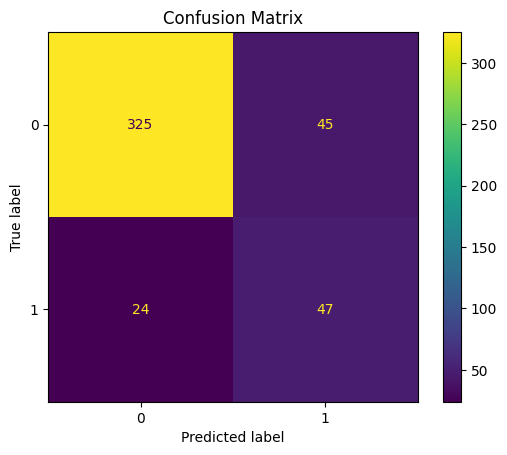

In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

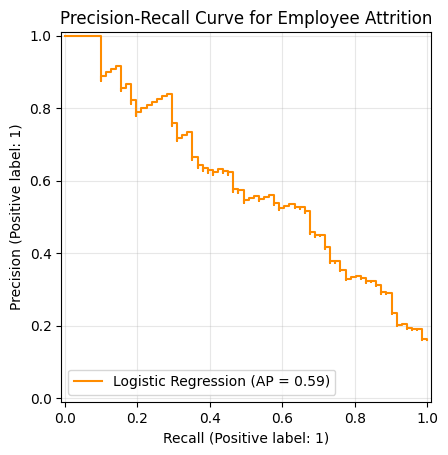

In [42]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Using the y_test and y_proba from your existing code
display = PrecisionRecallDisplay.from_predictions(
    y_test, 
    y_proba, 
    name="Logistic Regression",
    color="darkorange" # You can customize the line color
)

# Customize the plot
plt.title("Precision-Recall Curve for Employee Attrition")
plt.grid(alpha=0.3) # Adds a light grid for readability
plt.show()

In [43]:
joblib.dump(pipeline, '../pipeline.pkl')
joblib.dump(X_train,  '../X_train.pkl')

['../X_train.pkl']

In [44]:
import shap

# Step 1: Create SHAP explainer
# Use the scaler from the pipeline to transform test data first
X_train_scaled = pipeline.named_steps['scaler'].transform(X_train)
X_test_scaled = pipeline.named_steps['scaler'].transform(X_test)
# Step 2: Create explainer using the logistic regression model
explainer = shap.LinearExplainer(
    pipeline.named_steps['model'],
    X_train_scaled
)

# Step 3: Compute SHAP values
shap_values = explainer.shap_values(X_test_scaled)

In [45]:
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_scaled,
    feature_names=X_test.columns.tolist()
)


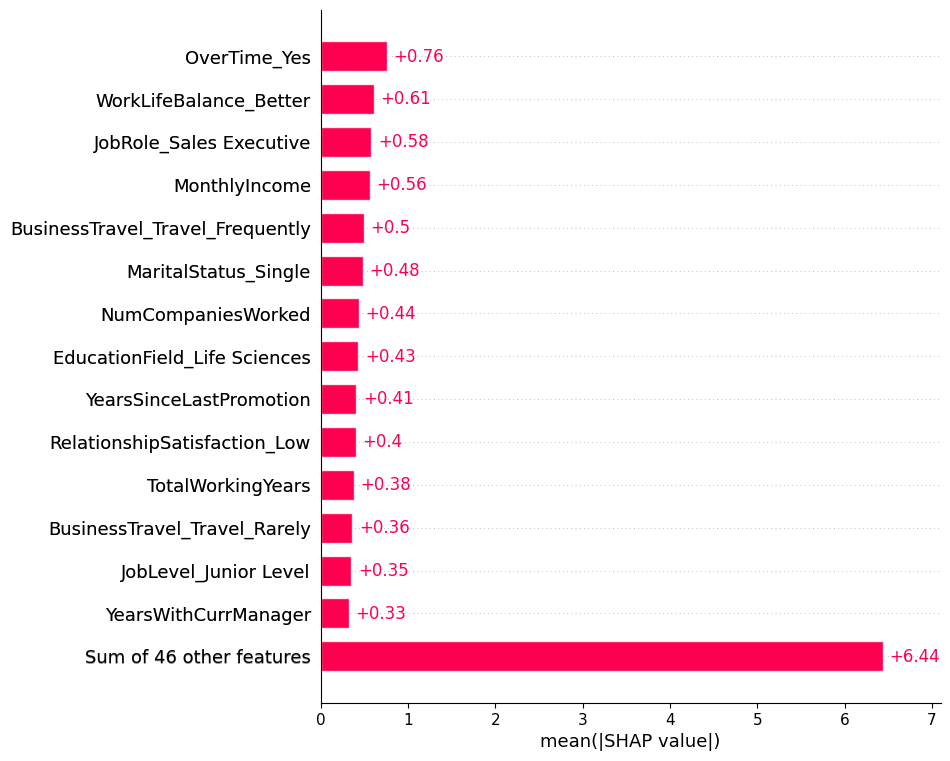

In [46]:
shap.plots.bar(explanation, max_display=15)

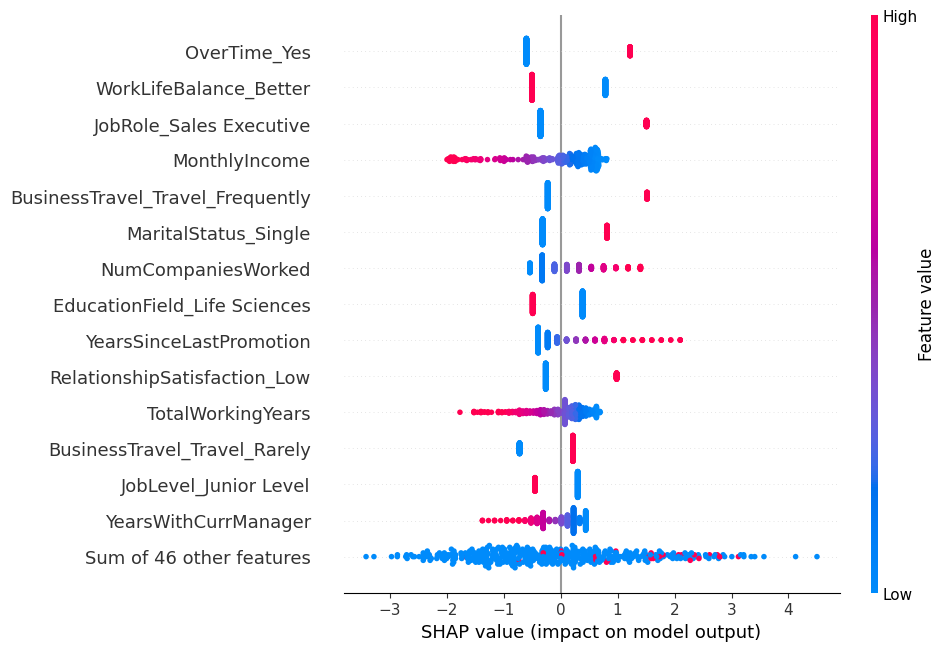

In [47]:
shap.plots.beeswarm(explanation, max_display=15)


Employee Details:
Age                                      37
DailyRate                              1040
DistanceFromHome                          2
HourlyRate                              100
MonthlyIncome                          5163
MonthlyRate                           15850
NumCompaniesWorked                        5
PercentSalaryHike                        14
StockOptionLevel                          1
TotalWorkingYears                        17
TrainingTimesLastYear                     2
YearsAtCompany                            1
YearsInCurrentRole                        0
YearsSinceLastPromotion                   0
YearsWithCurrManager                      0
BusinessTravel_Travel_Frequently      False
BusinessTravel_Travel_Rarely          False
Department_Research & Development      True
Department_Sales                      False
Education_Below College               False
Education_College                      True
Education_Doctor                      False
Education_Mast

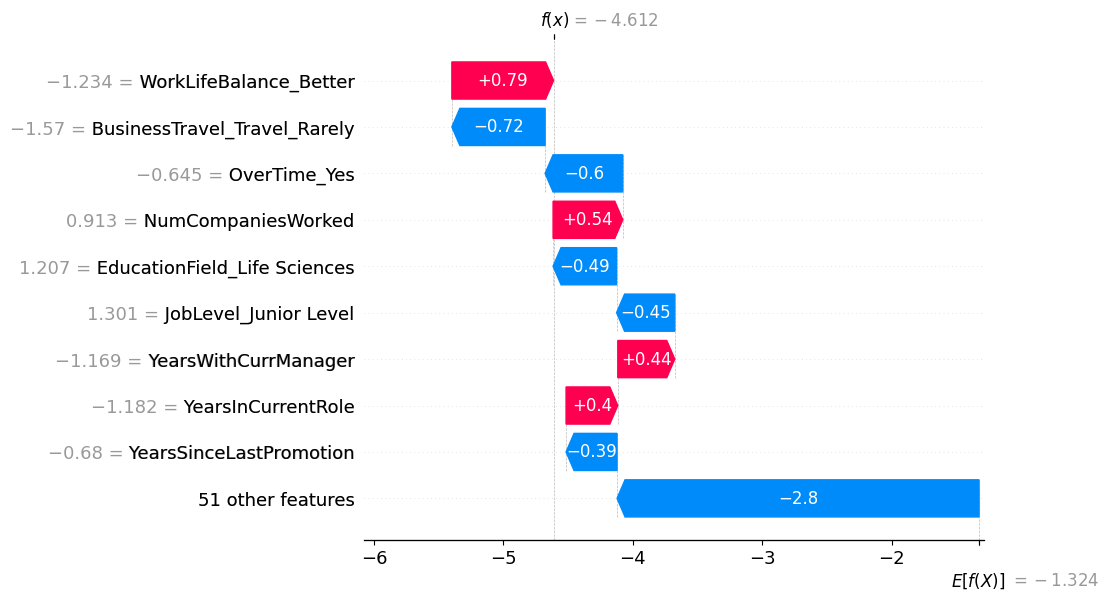

In [48]:
# Pick which test sample you want to explain
sample_idx = 5

# Get the actual employee's details from the original (unscaled) test set
employee = X_test.iloc[sample_idx]
print("Employee Details:")
print(employee)
print(f"\nActual Attrition: {y_test.iloc[sample_idx]}")
print(f"Predicted Probability: {y_proba[sample_idx]:.4f}")
print(f"Predicted Label: {y_pred[sample_idx]}")

# Then plot the waterfall for that same employee
shap.plots.waterfall(explanation[sample_idx])

Original DataFrame index: 293
Positional index in X_test: 12
Age                                      26
DailyRate                               950
DistanceFromHome                          4
HourlyRate                               48
MonthlyIncome                          5828
MonthlyRate                            8450
NumCompaniesWorked                        1
PercentSalaryHike                        12
StockOptionLevel                          0
TotalWorkingYears                         8
TrainingTimesLastYear                     0
YearsAtCompany                            8
YearsInCurrentRole                        7
YearsSinceLastPromotion                   7
YearsWithCurrManager                      4
BusinessTravel_Travel_Frequently      False
BusinessTravel_Travel_Rarely           True
Department_Research & Development     False
Department_Sales                       True
Education_Below College               False
Education_College                     False
Education_Docto

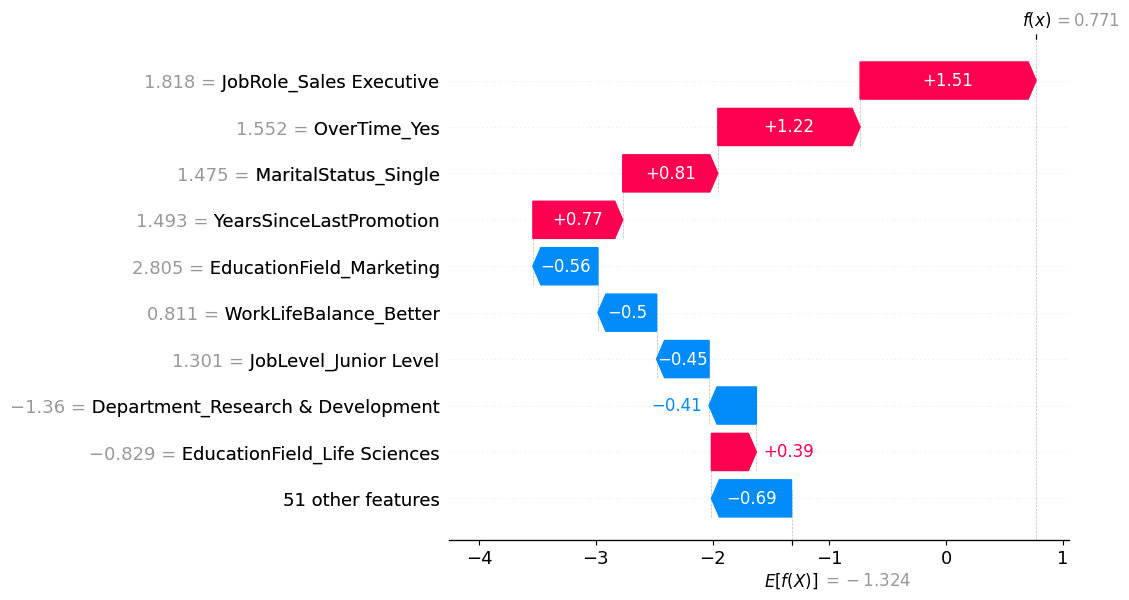

Base Value: -1.324385067752227
SHAP Values: [ 2.84615950e-01 -6.04829784e-02 -2.02598346e-01  4.18457088e-02
  1.04516828e-01 -4.04338234e-02 -3.23202415e-01  1.18923366e-01
  2.08528814e-01  1.98358111e-01  3.47793707e-01  2.08262601e-02
 -2.27637056e-01  7.69692556e-01  1.38627325e-02 -2.26734276e-01
  2.15208901e-01 -4.05385029e-01  6.01863514e-02 -6.06862641e-03
  1.22405160e-02 -1.41790738e-03  1.13147796e-01  3.85488522e-01
 -5.56855424e-01  1.84016155e-01  5.08103700e-02  2.01248948e-02
 -1.90165473e-01  9.34774654e-02 -2.73237847e-01  2.15552601e-01
 -7.15103922e-02 -9.02144973e-03  1.76321102e-02 -1.32669488e-01
 -4.49804885e-01 -1.55119696e-01 -5.96374986e-02 -4.69363284e-02
 -1.46736955e-01  2.68716924e-02 -3.50084660e-02  1.11662040e-01
  1.03242913e-01  1.50789886e+00 -1.70489577e-01 -1.09528720e-01
 -6.97865416e-02 -3.77415279e-01 -1.87664187e-01  8.14417942e-01
  1.21880985e+00 -4.76558197e-02 -2.61355330e-01  2.26574676e-02
 -1.33427190e-02  4.90250926e-02 -5.02574751e-

In [49]:
# Get all indices where actual attrition = 1
attrition_indices = y_test[y_test == 1].index

# Pick the first one
sample_idx = y_test.index.get_loc(attrition_indices[0])

print(f"Original DataFrame index: {attrition_indices[0]}")
print(f"Positional index in X_test: {sample_idx}")

# Now use it
print(X_test.iloc[sample_idx])
print(f"\nActual Attrition: {y_test.iloc[sample_idx]}")
print(f"Predicted Probability: {y_proba[sample_idx]:.4f}")

shap.plots.waterfall(explanation[sample_idx])

# Select the specific sample
exp_slice = explanation[sample_idx]

# 1. The Base Value (Starting point)
base_value = exp_slice.base_values
print(f"Base Value: {base_value}")

# 2. The SHAP values (The 'bars' in the waterfall)
# These represent the change from the base value
contributions = exp_slice.values
print(f"SHAP Values: {contributions}")

# 3. The Feature names and their actual values
feature_names = exp_slice.feature_names
raw_values = exp_slice.data

# Putting it all together in a readable format
import pandas as pd

df = pd.DataFrame({
    'Feature': feature_names,
    'Feature Value': raw_values,
    'SHAP Contribution': contributions
})

print("\nWaterfall Data Summary:")
print(df)
print(f"\nFinal Prediction: {base_value + contributions.sum()}")

Attrition Probability: 0.1356
Predicted Label: No


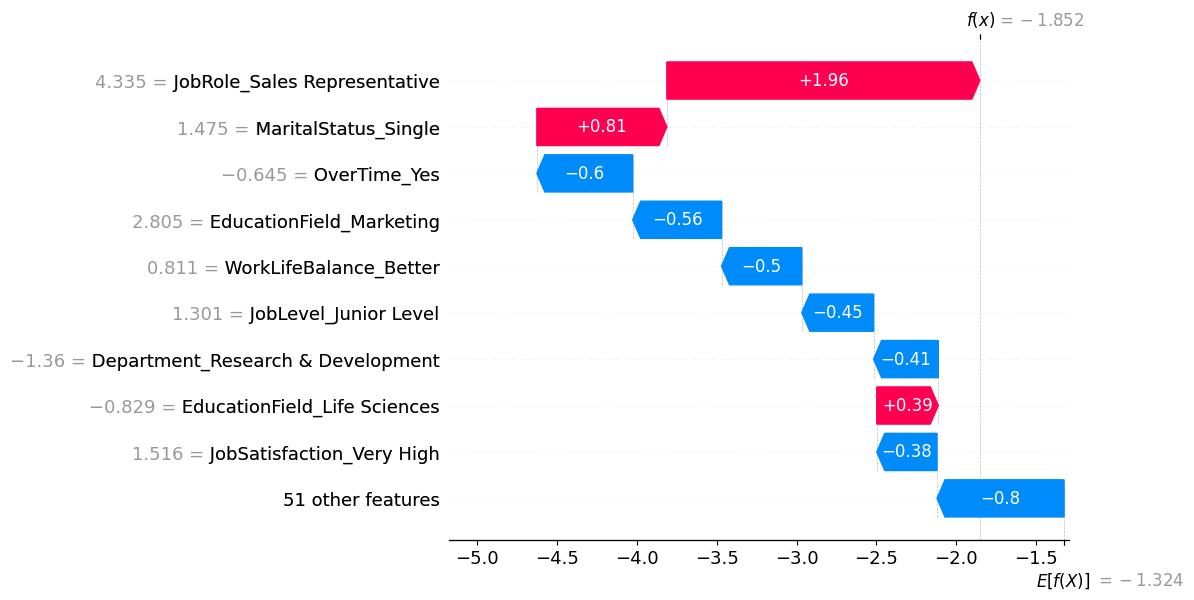

In [50]:
# Step 1: Create new employee with same columns as X_train
new_employee = pd.DataFrame([{
    'Age': 26,
    'DailyRate': 950,
    'DistanceFromHome': 4,
    'HourlyRate': 48,
    'MonthlyIncome': 5828,
    'MonthlyRate': 8450,
    'NumCompaniesWorked': 1,
    'PercentSalaryHike': 12,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 8,
    'TrainingTimesLastYear': 0,
    'YearsAtCompany': 8,
    'YearsInCurrentRole': 7,
    'YearsSinceLastPromotion': 3,
    'YearsWithCurrManager': 4,
    'BusinessTravel_Travel_Rarely':     True,
    'Department_Research & Development':     False,
    'Department_Sales':                       True,
    'Education_Below College':               False,
    'Education_College':                     False,
    'Education_Doctor':                      False,
    'Education_Master':                       True,
    'EducationField_Life Sciences':          False,
    'EducationField_Marketing':               True,
    'EducationField_Medical':                False,
    'EducationField_Other':                  False,
    'EducationField_Technical Degree':       False,
    'EnvironmentSatisfaction_Low':           False,
    'EnvironmentSatisfaction_Medium':        False,
    'EnvironmentSatisfaction_Very High':      True,
    'Gender_Male':                            True,
    'JobInvolvement_Low':                    False,
    'JobInvolvement_Medium':                  True,
    'JobInvolvement_Very High':              False,
    'JobLevel_Executive Level':              False,
    'JobLevel_Junior Level':                  True,
    'JobLevel_Mid Level':                    False,
    'JobLevel_Senior Level':                 False,
    'JobRole_Human Resources':               False,
    'JobRole_Laboratory Technician':         False,
    'JobRole_Manager':                       False,
    'JobRole_Manufacturing Director':        False,
    'JobRole_Research Director':             False,
    'JobRole_Research Scientist':            False,
    'JobRole_Sales Executive':                False,
    'JobRole_Sales Representative':          True,
    'JobSatisfaction_Low':                   False,
    'JobSatisfaction_Medium':                False,
    'JobSatisfaction_Very High':              True,
    'MaritalStatus_Married':                 False,
    'MaritalStatus_Single':                   True,
    'OverTime_Yes':                           False,
    'PerformanceRating_Outstanding':         False,
    'RelationshipSatisfaction_Low':          False,
    'RelationshipSatisfaction_Medium':        True,
    'RelationshipSatisfaction_Very High':     False,
    'WorkLifeBalance_Best':                   True,
    'WorkLifeBalance_Better':                  True,
    'WorkLifeBalance_Good':                   False
}])


    # ... fill in ALL columns that exist in X_train

# Step 2: Make sure columns match exactly
new_employee = new_employee.reindex(columns=X_train.columns, fill_value=0)

# Step 3: Predict using pipeline (scaling is handled automatically)
proba = pipeline.predict_proba(new_employee)[:, 1][0]
pred = (proba >= 0.61).astype(int)

print(f"Attrition Probability: {proba:.4f}")
print(f"Predicted Label: {'Yes' if pred == 1 else 'No'}")

# Step 4: SHAP explanation
new_employee_scaled = pipeline.named_steps['scaler'].transform(new_employee)

new_explanation = shap.Explanation(
    values=explainer.shap_values(new_employee_scaled),
    base_values=explainer.expected_value,
    data=new_employee_scaled,
    feature_names=X_train.columns.tolist()
)

shap.plots.waterfall(new_explanation[0])

In [51]:
# sample index 5, Predicted Probability: 0.0088
new_employee = {'Age': 37, 'BusinessTravel': 'Travel_Frequently', 'DailyRate': 1040, 'Department': 'Research & Development', 'DistanceFromHome': 2, 'Education': 'College', 'EducationField': 'Life Sciences', 'EnvironmentSatisfaction': 'Medium', 'Gender': 'Male', 'HourlyRate': 100, 'JobInvolvement': 'Medium', 'JobLevel': 'Junior Level', 'JobRole': 'Healthcare Representative', 'JobSatisfaction': 'Very High', 'MaritalStatus': 'Divorced', 'MonthlyIncome': 5163, 'MonthlyRate': 15850, 'NumCompaniesWorked': 5, 'OverTime': 'Yes', 'PercentSalaryHike': 14, 'PerformanceRating': 'Excellent', 'RelationshipSatisfaction': 'Medium', 'StockOptionLevel': 1, 'TotalWorkingYears': 17, 'TrainingTimesLastYear': 2, 'WorkLifeBalance': 'Bad', 'YearsAtCompany': 1, 'YearsInCurrentRole': 0, 'YearsSinceLastPromotion': 1, 'YearsWithCurrManager': 1}


In [52]:
pipeline = joblib.load("../pipeline.pkl")
X_train = joblib.load("../X_train.pkl")
df_original = joblib.load("../df_original.pkl")

In [53]:
raw_df = pd.DataFrame([new_employee])

temp = pd.concat([df_original.drop(columns='Attrition'), raw_df], ignore_index=True)

encoded = pd.get_dummies(temp, drop_first=True).tail(1)
encoded.head()

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,...,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,PerformanceRating_Outstanding,RelationshipSatisfaction_Low,RelationshipSatisfaction_Medium,RelationshipSatisfaction_Very High,WorkLifeBalance_Best,WorkLifeBalance_Better,WorkLifeBalance_Good
1470,37,1040,2,100,5163,15850,5,14,1,17,...,False,False,True,False,False,True,False,False,False,False


In [54]:

aligned = encoded.reindex(columns=X_train.columns, fill_value=0)
print(aligned.filter(like="BusinessTravel").T)
proba = pipeline.predict_proba(aligned)[0][1]

pred = (proba >= 0.61).astype(int)

print(f"Attrition Probability: {proba:.4f}")
print(f"Predicted Label: {'Yes' if pred == 1 else 'No'}")

                                   1470
BusinessTravel_Travel_Frequently   True
BusinessTravel_Travel_Rarely      False
Attrition Probability: 0.2753
Predicted Label: No


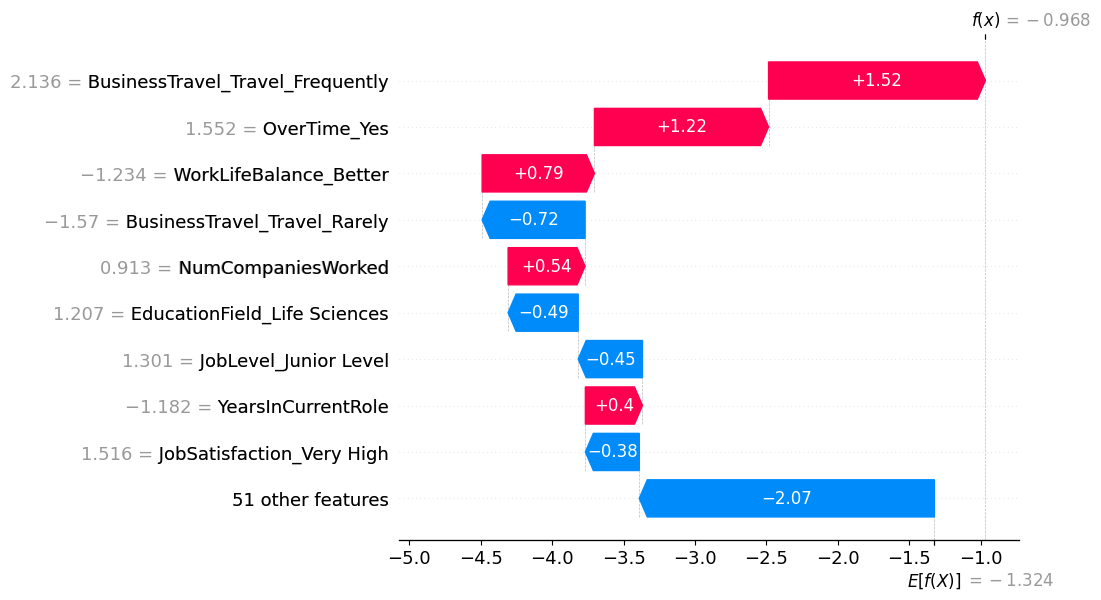

In [55]:
new_employee_scaled = pipeline.named_steps['scaler'].transform(aligned)
shap_values = explainer.shap_values(new_employee_scaled)
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]
new_explanation = shap.Explanation(
    values=shap_values[0],              # ✅ FIX: 1D
    base_values=base_val,               # ✅ FIX: scalar
    data=new_employee_scaled[0],        # ✅ FIX: 1D
    feature_names=X_train.columns.tolist()
)

shap.plots.waterfall(new_explanation)

In [56]:
coef = pipeline.named_steps['model'].coef_[0]
feature_names = X_train.columns

for f, c in zip(feature_names, coef):
    if "BusinessTravel" in f:
        print(f, c)

BusinessTravel_Travel_Frequently 0.6697543422963446
BusinessTravel_Travel_Rarely 0.42398528517423284


In [57]:
df_original['BusinessTravel'].value_counts(normalize=True)

BusinessTravel
Travel_Rarely        0.709524
Travel_Frequently    0.188435
Non-Travel           0.102041
Name: proportion, dtype: float64

In [58]:
df_original['BusinessTravel'].value_counts(normalize=True)

BusinessTravel
Travel_Rarely        0.709524
Travel_Frequently    0.188435
Non-Travel           0.102041
Name: proportion, dtype: float64